# Bank Loan Analysis Using Python

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [3]:
df=pd.read_excel("C:/Users/ASUS/OneDrive/Desktop/BANK LOAN DA PROJECT/financial_loan_data_excel.xlsx")

In [4]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [5]:
print("No. of Rows:",df.shape[0])

No. of Rows: 38576


In [6]:
print("No. of Columns:",df.shape[1])

No. of Columns: 24


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

In [8]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


In [9]:
#Total loan applications

total_loan_applications=df['id'].count()
print("Total Loan Applications:",total_loan_applications)

Total Loan Applications: 38576


In [10]:
#MTD total loan applications

latest_issue_date=df['issue_date'].max()
latest_year=latest_issue_date.year
latest_month=latest_issue_date.month
mtd_data=df[(df['issue_date'].dt.year==latest_year) & (df['issue_date'].dt.month==latest_month)]
mtd_loan_applications=mtd_data['id'].count
print("MTD Loan Applications:",mtd_loan_applications)
    

MTD Loan Applications: <bound method Series.count of 13       1020855
15       1060995
16       1046507
18       1059497
42        472634
          ...   
38496    1026558
38516     633392
38531    1052169
38535     624384
38546     634116
Name: id, Length: 4314, dtype: int64>


In [11]:
#Total Funded Amount

total_funded_amount=df['loan_amount'].sum()
total_funded_amount_millions=total_funded_amount/1000000
print("Total Funded Amount: ${:.2f}M".format(total_funded_amount_millions))

Total Funded Amount: $435.76M


In [12]:
# MTD Total Funded Amount

latest_issue_date=df['issue_date'].max()
latest_year=latest_issue_date.year
latest_month=latest_issue_date.month
mtd_data=df[(df['issue_date'].dt.year==latest_year) & (df['issue_date'].dt.month==latest_month)]

mtd_total_funded_amount=mtd_data['loan_amount'].sum()
mtd_total_funded_amount_millions=mtd_total_funded_amount/1000000
print("MTD Total Funded Amount ${:.2f}M".format(mtd_total_funded_amount_millions))

MTD Total Funded Amount $53.98M


In [13]:
#Total Amount Received

total_amount_received=df['total_payment'].sum()
total_amount_received_millions=total_amount_received/1000000
print("Total Amount Recieved: ${:.2f}M".format(total_amount_received_millions))

Total Amount Recieved: $473.07M


In [14]:
#MTD Total Amount Received

latest_issue_date=df['issue_date'].max()
latest_year=latest_issue_date.year
latest_month=latest_issue_date.month
mtd_data=df[(df['issue_date'].dt.year==latest_year) & (df['issue_date'].dt.month==latest_month)]

mtd_total_amount_received=mtd_data['total_payment'].sum()
mtd_total_amount_received_millions=mtd_total_amount_received/1000000
print("MTD Total Amount Received ${:.2f}M".format(mtd_total_amount_received_millions))

MTD Total Amount Received $58.07M


In [15]:
#Average Interest Rate

average_interest_rate=df['int_rate'].mean()*100
print("Avg Interest Rate:{:.2f}%".format(average_interest_rate))

Avg Interest Rate:12.05%


In [16]:
# Average Debt to income ratio (DTI)

average_dti=df['dti'].mean()*100
print("Avg DTI:{:.2f}%".format(average_dti))

Avg DTI:13.33%


In [17]:
# GOOD LOAN METRICS

good_loans = df[df['loan_status'].isin(["Fully Paid", "Current"])]

total_loan_applications = df['id'].count()

good_loan_applications = good_loans['id'].count()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received = good_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount / 1000000
good_loan_received_millions = good_loan_received / 1000000

good_loan_percentage = (good_loan_applications / total_loan_applications) * 100

print("Good Loan Applications:", good_loan_applications)
print("Good Loan Funded Amount (in Millions): ${:.2f}M".format(good_loan_funded_amount_millions))
print("Good Loan Total Received (in Millions): ${:.2f}M".format(good_loan_received_millions))
print("Percentage of Good Loan Applications: {:.2f}%".format(good_loan_percentage))

Good Loan Applications: 33243
Good Loan Funded Amount (in Millions): $370.22M
Good Loan Total Received (in Millions): $435.79M
Percentage of Good Loan Applications: 86.18%


In [18]:
# BAD LOAN METRICS

bad_loans = df[df['loan_status'].isin(["Charged Off"])]

total_loan_applications = df['id'].count()

bad_loan_applications = bad_loans['id'].count()
bad_loan_funded_amount = bad_loans['loan_amount'].sum()
bad_loan_received = bad_loans['total_payment'].sum()

bad_loan_funded_amount_millions = bad_loan_funded_amount / 1000000
bad_loan_received_millions = bad_loan_received / 1000000

bad_loan_percentage = (bad_loan_applications / total_loan_applications) * 100

print("Bad Loan Applications:", bad_loan_applications)
print("Bad Loan Funded Amount (in Millions): ${:.2f}M".format(bad_loan_funded_amount_millions))
print("Bad Loan Total Received (in Millions): ${:.2f}M".format(bad_loan_received_millions))
print("Percentage of Bad Loan Applications: {:.2f}%".format(bad_loan_percentage))

Bad Loan Applications: 5333
Bad Loan Funded Amount (in Millions): $65.53M
Bad Loan Total Received (in Millions): $37.28M
Percentage of Bad Loan Applications: 13.82%


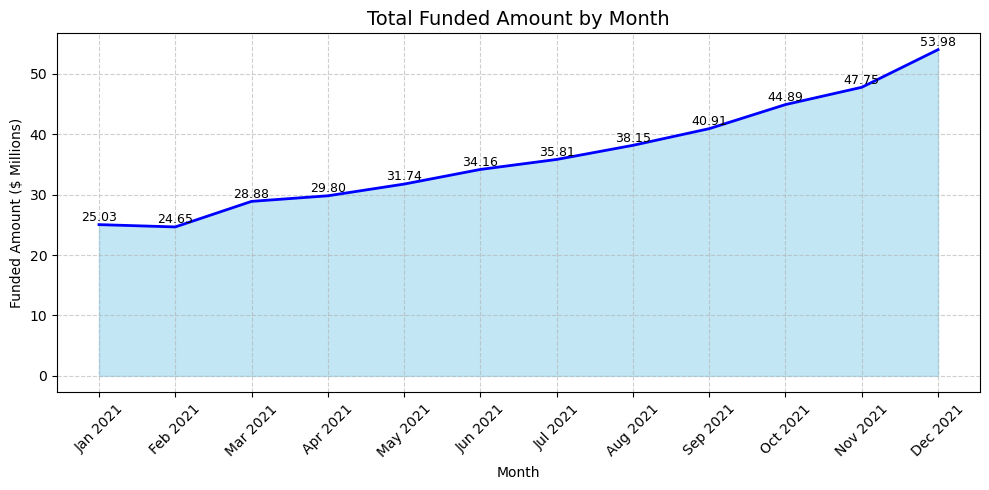

In [19]:
# MONTHLY TRENDS BY ISSUE DATE FOR TOTAL FUNDED AMOUNT

monthly_funded = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['loan_amount']
      .sum()
      .div(1_000_000)
      .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10, 5))
plt.fill_between(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='skyblue',
    alpha=0.5
)
plt.plot(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='blue',
    linewidth=2
)

for i, row in monthly_funded.iterrows():
    plt.text(
        i,
        row['loan_amount_millions'] + 0.1,
        f"{row['loan_amount_millions']:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0,
        color='black'
    )

plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount ($ Millions)')
plt.xticks(
    ticks=range(len(monthly_funded)),
    labels=monthly_funded['month_name'],
    rotation=45
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

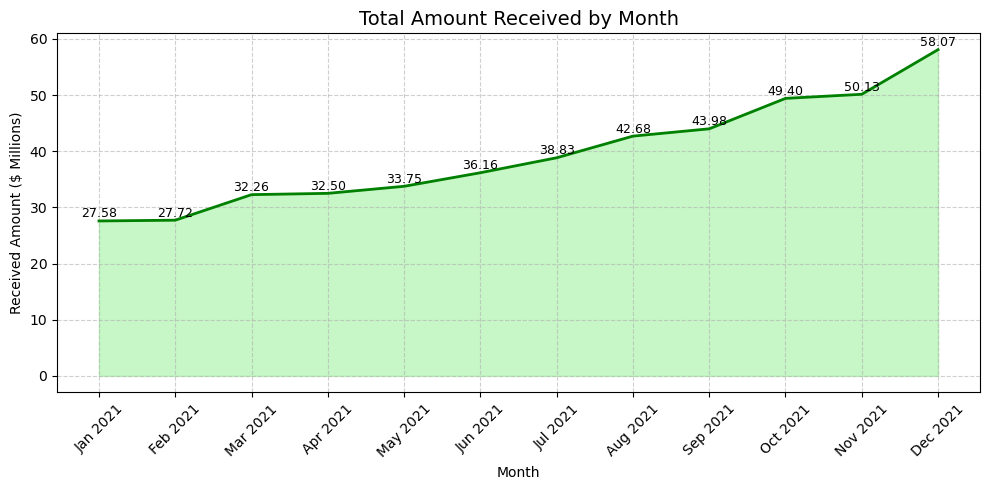

In [20]:
# MONTHLY TRENDS BY ISSUE DATE FOR TOTAL AMOUNT RECEIVED


monthly_received = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['total_payment']
      .sum()
      .div(1_000_000)
      .reset_index(name='received_amount_millions')
)

plt.figure(figsize=(10, 5))
plt.fill_between(
    monthly_received['month_name'],
    monthly_received['received_amount_millions'],
    color='lightgreen',
    alpha=0.5
)
plt.plot(
    monthly_received['month_name'],
    monthly_received['received_amount_millions'],
    color='green',
    linewidth=2
)

for i, row in monthly_received.iterrows():
    plt.text(
        i,
        row['received_amount_millions'] + 0.1,
        f"{row['received_amount_millions']:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0,
        color='black'
    )

plt.title('Total Amount Received by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received Amount ($ Millions)')
plt.xticks(
    ticks=range(len(monthly_received)),
    labels=monthly_received['month_name'],
    rotation=45
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

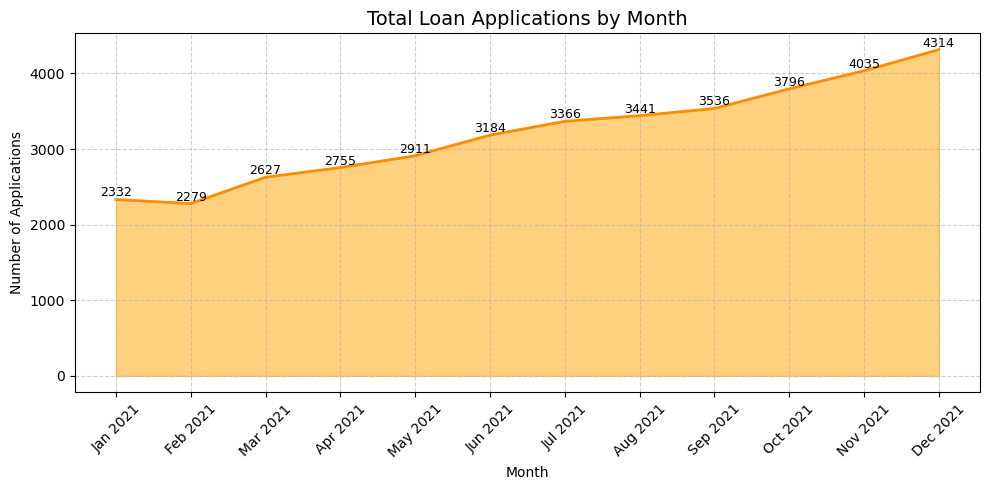

In [21]:
# MONTHLY TRENDS BY ISSUE DATE FOR TOTAL LOAN APPLICATIONS

monthly_applications = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['id']
      .count()
      .reset_index(name='loan_applications_count')
)

plt.figure(figsize=(10, 5))
plt.fill_between(
    monthly_applications['month_name'],
    monthly_applications['loan_applications_count'],
    color='orange',
    alpha=0.5
)
plt.plot(
    monthly_applications['month_name'],
    monthly_applications['loan_applications_count'],
    color='darkorange',
    linewidth=2
)

for i, row in monthly_applications.iterrows():
    plt.text(
        i,
        row['loan_applications_count'] + 0.5,
        f"{row['loan_applications_count']}",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0,
        color='black'
    )

plt.title('Total Loan Applications by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.xticks(
    ticks=range(len(monthly_applications)),
    labels=monthly_applications['month_name'],
    rotation=45
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

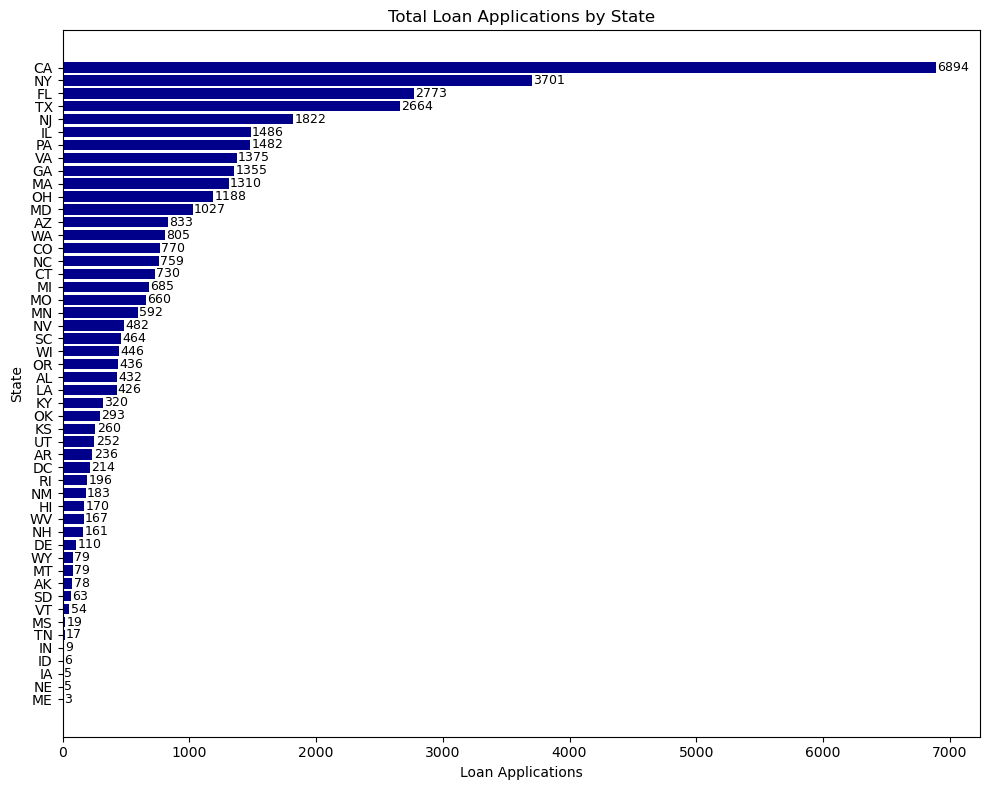

In [22]:
# REGIONAL ANALYSIS FOR TOTAL LOAN APPLICATION BY STATE

state_applications_thousands = df.groupby('address_state')['id'].count().sort_values(ascending=True)


plt.figure(figsize=(10, 8))

bars = plt.barh(
    state_applications_thousands.index,
    state_applications_thousands.values,
    color='darkblue'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.0f}',
        va='center',
        fontsize=9
    )

plt.title('Total Loan Applications by State')
plt.xlabel('Loan Applications')
plt.ylabel('State')
plt.tight_layout()
plt.show()

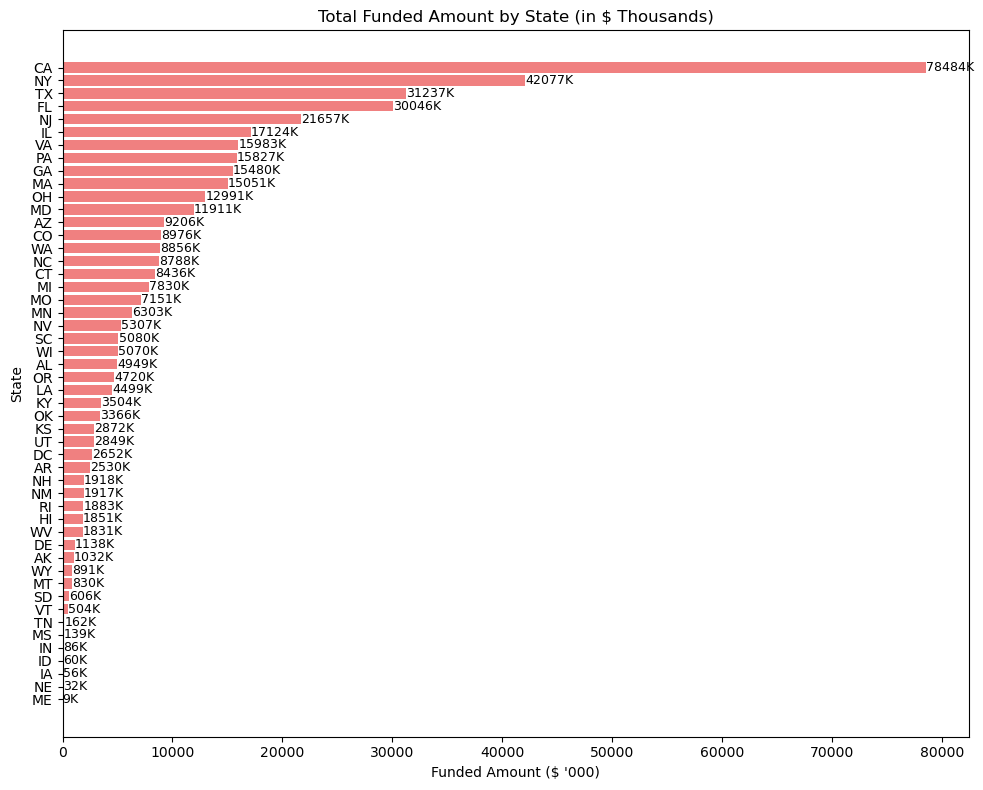

In [23]:
# REGIONAL ANALYSIS BY STATE FOR TOTAL FUNDED AMOUNT

state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding / 1000

plt.figure(figsize=(10, 8))

bars = plt.barh(
    state_funding_thousands.index,
    state_funding_thousands.values,
    color='lightcoral'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.0f}K',
        va='center',
        fontsize=9
    )

plt.title('Total Funded Amount by State (in $ Thousands)')
plt.xlabel('Funded Amount ($ \'000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

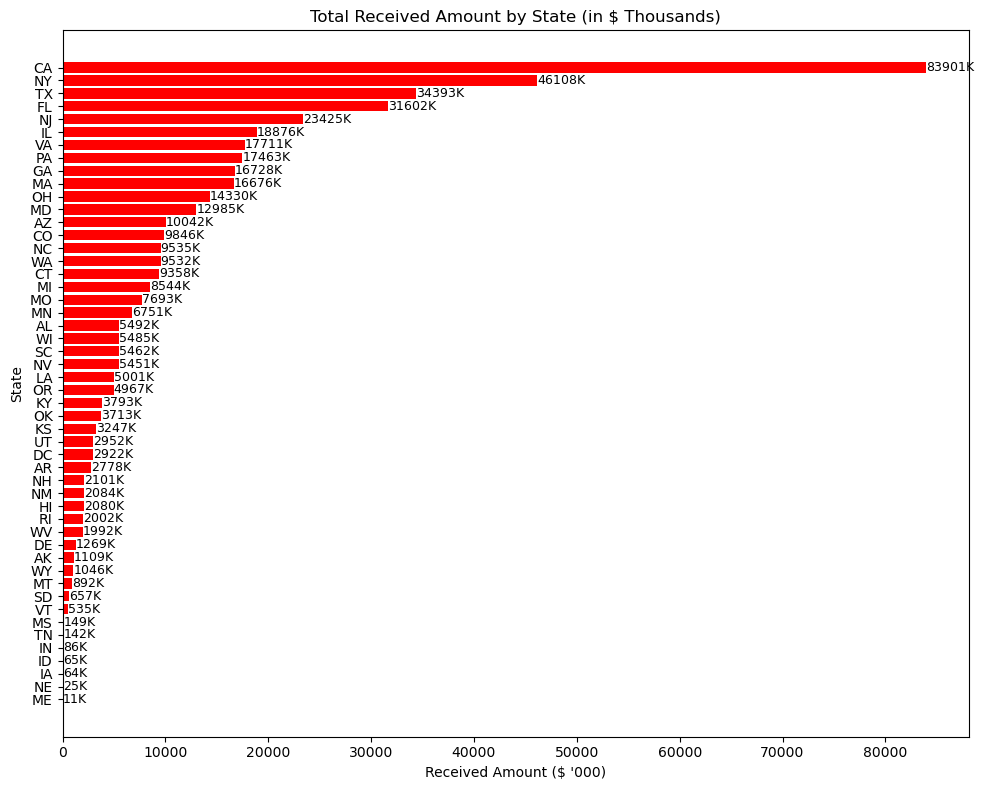

In [24]:
# REGIONAL ANALYSIS BY STATE FOR TOTAL AMOUNT RECEIVED

state_received = df.groupby('address_state')['total_payment'].sum().sort_values(ascending=True)
state_received_thousands = state_received / 1000

plt.figure(figsize=(10, 8))

bars = plt.barh(
    state_received_thousands.index,
    state_received_thousands.values,
    color='red'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.0f}K',
        va='center',
        fontsize=9
    )

plt.title('Total Received Amount by State (in $ Thousands)')
plt.xlabel('Received Amount ($ \'000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

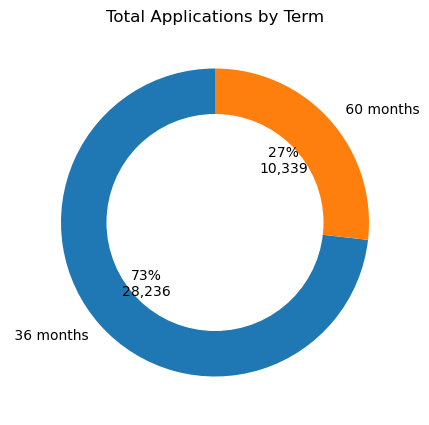

In [25]:
# LOAN TERM ANALYSIS FOR TOTAL APPLICATIONS

total_applications_term = df.groupby('term')['id'].count()

plt.figure(figsize=(5, 5))

plt.pie(
    total_applications_term,
    labels=total_applications_term.index,
    autopct=lambda p: f"{p:.0f}%\n{int(p * total_applications_term.sum() / 100):,}",
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))

plt.title("Total Applications by Term")
plt.show()

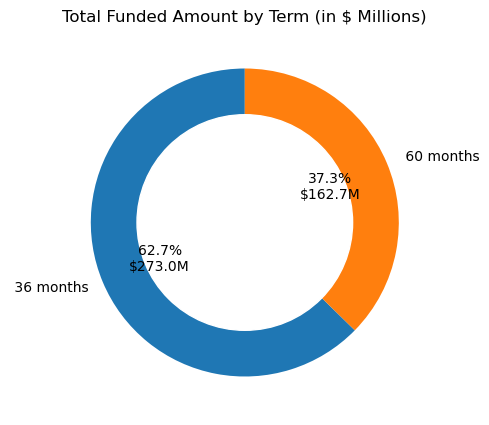

In [26]:
# LOAN TERM ANALYSIS FOR TOTAL FUNDED AMOUNT

term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1000000

plt.figure(figsize=(5, 5))

plt.pie(
    term_funding_millions,
    labels=term_funding_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M",
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))

plt.title("Total Funded Amount by Term (in $ Millions)")
plt.show()

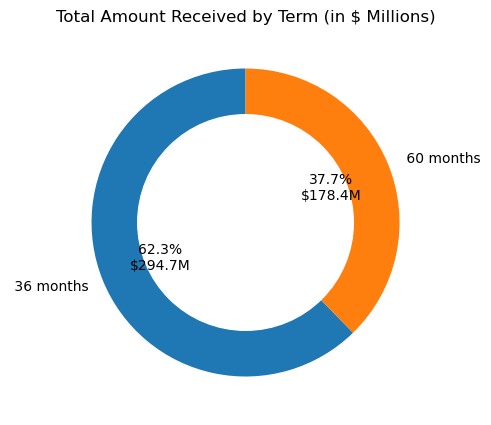

In [27]:
# LOAN TERM ANALYSIS FOR TOTAL AMOUNT RECEIVED

term_received_millions = df.groupby('term')['total_payment'].sum() / 1000000

plt.figure(figsize=(5, 5))

plt.pie(
    term_received_millions,
    labels=term_received_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p*sum(term_received_millions)/100:.1f}M",
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))

plt.title("Total Amount Received by Term (in $ Millions)")
plt.show()

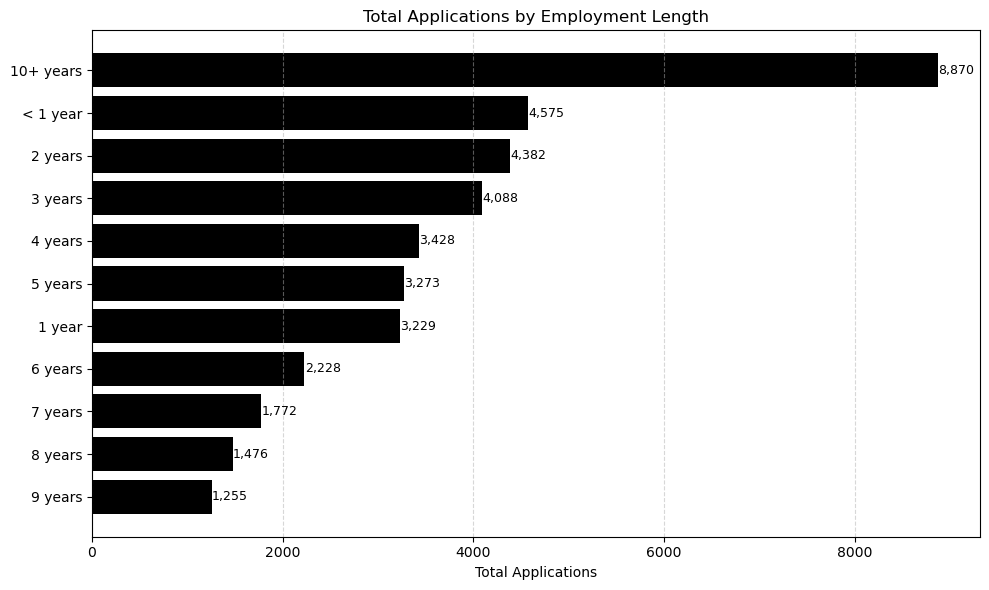

In [28]:
# TOTAL APPLICATIONS FOR EMPLOYEE LENGTH

application_emp_length = df.groupby('emp_length')['id'].count().sort_values()

plt.figure(figsize=(10, 6))

bars = plt.barh(
    application_emp_length.index,
    application_emp_length.values,
    color='black'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}',
        va='center',
        fontsize=9
    )

plt.xlabel("Total Applications")
plt.title("Total Applications by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

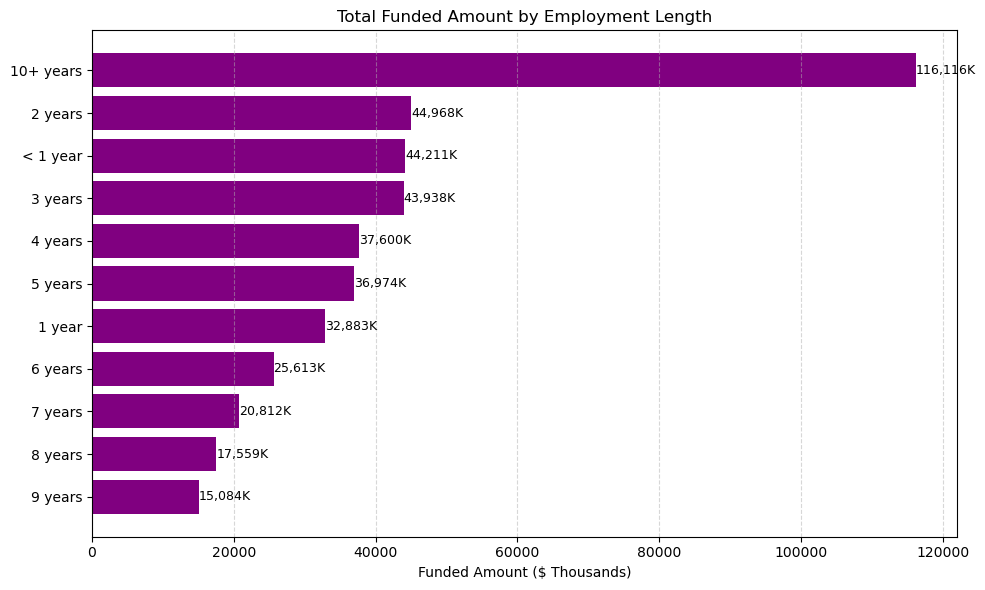

In [29]:
# EMPLOYEE LENGTH BY TOTAL FUNDED AMOUNT

emp_funding_thousands = df.groupby('emp_length')['loan_amount'].sum().sort_values() / 1000

plt.figure(figsize=(10, 6))

bars = plt.barh(
    emp_funding_thousands.index,
    emp_funding_thousands,
    color='purple'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}K',
        va='center',
        fontsize=9
    )

plt.xlabel("Funded Amount ($ Thousands)")
plt.title("Total Funded Amount by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

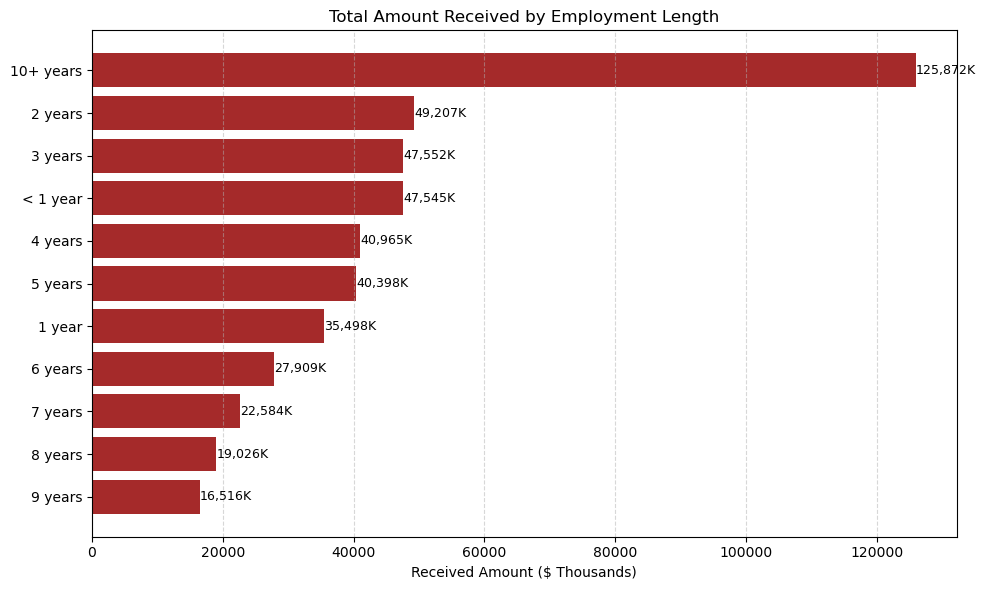

In [30]:
# EMPLOYEE LENGTH BY TOTAL AMOUNT RECEIVED

emp_received_thousands = df.groupby('emp_length')['total_payment'].sum().sort_values() / 1000

plt.figure(figsize=(10, 6))

bars = plt.barh(
    emp_received_thousands.index,
    emp_received_thousands,
    color='brown'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}K',
        va='center',
        fontsize=9
    )

plt.xlabel("Received Amount ($ Thousands)")
plt.title("Total Amount Received by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

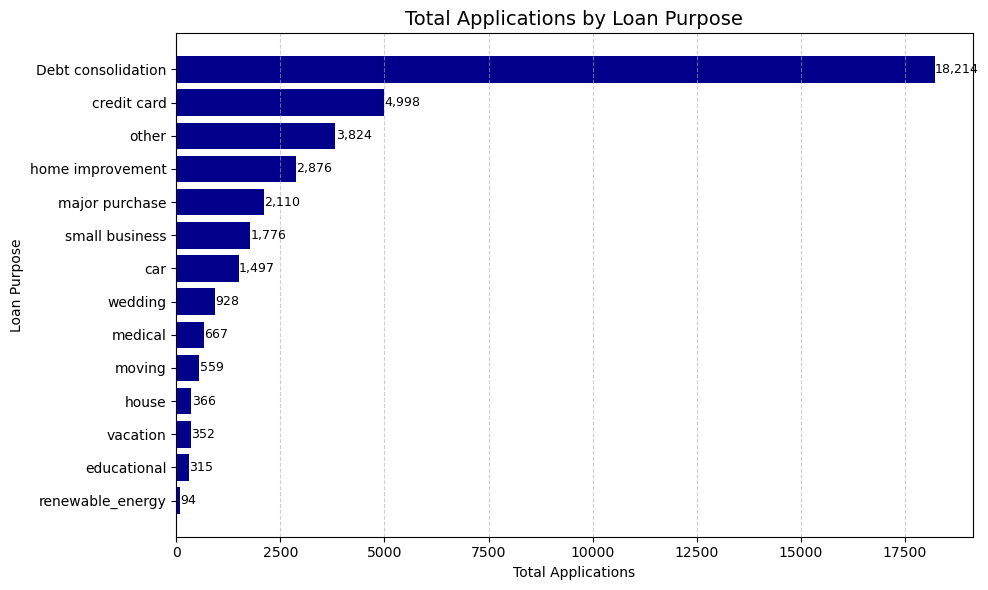

In [31]:
# TOTAL APPLICATIONS BY LOAN PURPOSE

purpose_total_applications = (
    df.groupby('purpose')['id']
      .count()
      .sort_values()
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    purpose_total_applications.index,
    purpose_total_applications.values,
    color='darkblue'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}',
        va='center',
        fontsize=9
    )

plt.title('Total Applications by Loan Purpose', fontsize=14)
plt.xlabel('Total Applications')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

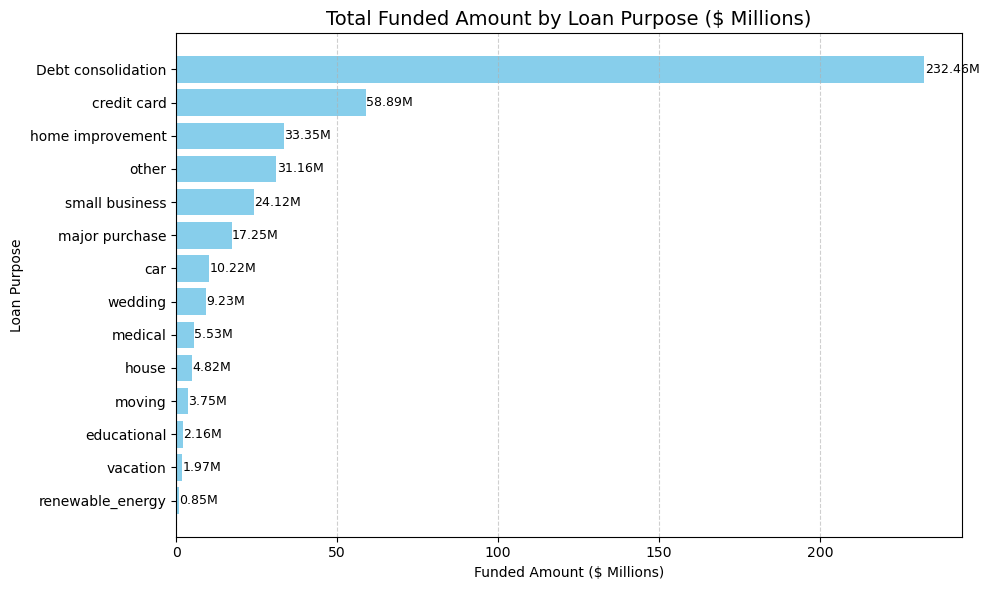

In [32]:
#LOAN PURPOSE BY TOTAL FUNDED AMOUNT


purpose_funding_millions = (
    df.groupby('purpose')['loan_amount']
      .sum()
      .sort_values() / 1000000
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    purpose_funding_millions.index,
    purpose_funding_millions.values,
    color='skyblue'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}M',
        va='center',
        fontsize=9
    )

plt.title('Total Funded Amount by Loan Purpose ($ Millions)', fontsize=14)
plt.xlabel('Funded Amount ($ Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

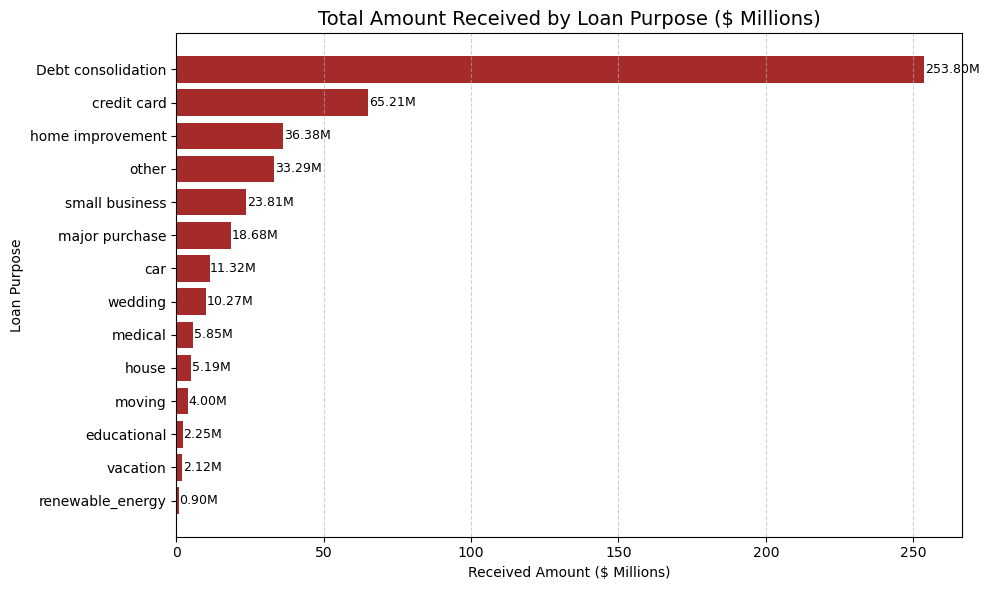

In [33]:
# LOAN PURPOSE BY TOTAL AMOUNT RECEIVED

purpose_received_millions = (
    df.groupby('purpose')['total_payment']
      .sum()
      .sort_values() / 1000000
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    purpose_received_millions.index,
    purpose_received_millions.values,
    color='brown'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}M',
        va='center',
        fontsize=9
    )

plt.title('Total Amount Received by Loan Purpose ($ Millions)', fontsize=14)
plt.xlabel('Received Amount ($ Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

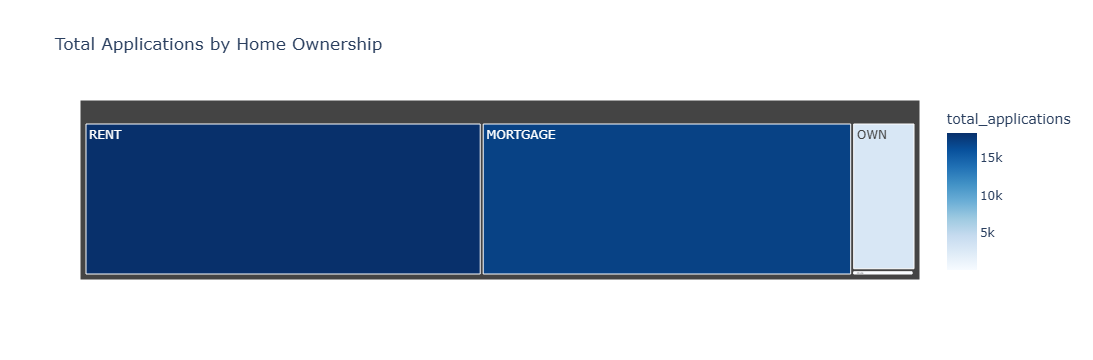

In [34]:
# TOTAL APPLICATIONS BY HOME OWNERSHIP

applications_home_ownership = (
    df.groupby('home_ownership')['id']
      .count()
      .reset_index(name='total_applications')
)

fig = px.treemap(
    applications_home_ownership,
    path=['home_ownership'],
    values='total_applications',
    color='total_applications',
    color_continuous_scale='Blues',
    title='Total Applications by Home Ownership'
)

fig.show()

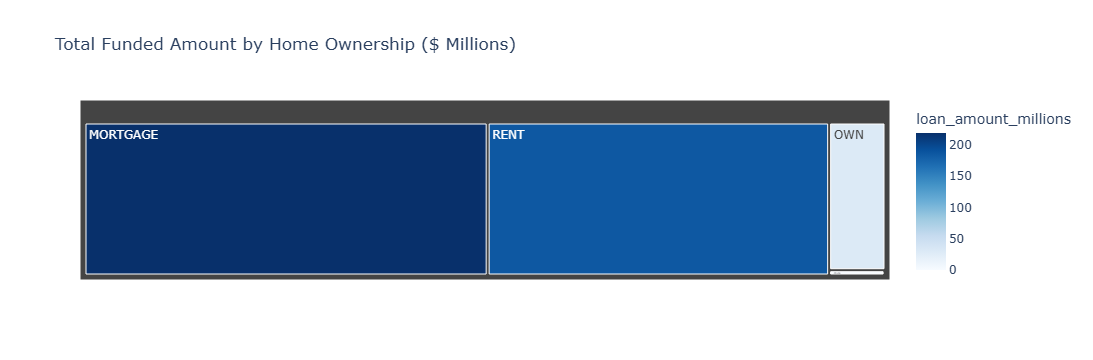

In [35]:
# HOME OWNERSHIP BY TOTAL FUNDED AMOUNT

home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions'] = home_funding['loan_amount'] / 1_000_000

fig = px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='Blues',
    title='Total Funded Amount by Home Ownership ($ Millions)'
)

fig.show()

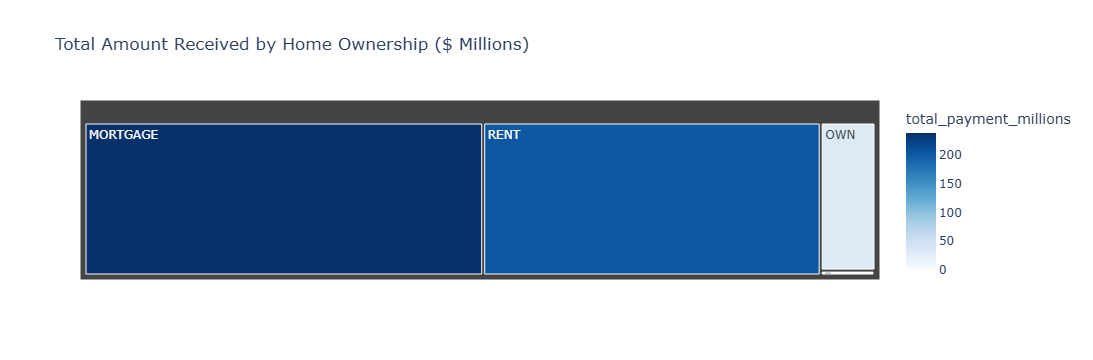

In [36]:
# HOME OWNERSHIP BY TOTAL AMOUNT RECCEIVED

home_received = df.groupby('home_ownership')['total_payment'].sum().reset_index()
home_received['total_payment_millions'] = home_received['total_payment'] / 1_000_000

fig = px.treemap(
    home_received,
    path=['home_ownership'],
    values='total_payment_millions',
    color='total_payment_millions',
    color_continuous_scale='Blues',
    title='Total Amount Received by Home Ownership ($ Millions)'
)

fig.show()